### Initializing instrumentation

In [1]:
# import packages
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time
from scipy.signal import find_peaks
from DataProcessing.Plot import PlotSaver

In [2]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [4]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [5]:
sr400 = SR400.SR400('GPIB0::23::INSTR', timeout = 1000)

In [6]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [7]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


### Defining the pulse sequence

In [8]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],              # MOT
                     [["B", 10e-6, 5e-6, 15],              # 780 EXC (20dB attenuator connected)
                      ["C", 10e-6, 5e-6, "TTL"]],          # 480 EXC
                     ["D", 20e-6, 0, 8],                   # DEI switch
                    ]

#pulse_arrangement = [["D", 20e-6, 0, 8]]                 # DEI switch
T = 1000e-6

cycle_number = 30
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

# stepper motor slope (for blue laser)
freq_factor = 129 * 2 # kHz

notes = {"gate_width": gate_width, "gate_delay": gate_delay}

In [9]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num = cycle_number, 
                  dwell = 0, sourceA = "INPUT1", sourceB = "INPUT2", gate_A_mode = "FIXED",
                  gate_A_delay = gate_delay, gate_A_width = gate_width, gate_B_mode = "CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [11]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [12]:
bnc575.start_pulses()

### Search for a Rydberg resonance

In [15]:
weeder.position(header = "A", query = True)

'A3250'

In [17]:
# begin stepper motor at initial position 1000, then move it out to increase the frequency
weeder.move("A", position = 3500, progress = True)

start at 1001 --> 3500.0 --> 3500
Old position: 1001
New position: 3500


In [26]:
# used to move motor incrementally to zero in on the location of a resonance
weeder.advance(header = "A", num_step = -10)

start at 2710 --> 2700.0 --> 2700
Old position: 2710
New position: 2700


### Generating Stark maps 

#### 1D map

In [26]:
center = 2700 + 250
stride = 2
half_width = 200

# scan list gneration
x_list = np.arange(2* half_width/stride)

In [45]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position - 100)
weeder.move(header = "A", position = start_position)

results = []
s = time.time()
for idx in x_list:
    print(f"Now checking step: {idx}", end = "\r", flush = True)
    sr400.count_reset()
    result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A", "+")
    time.sleep(0.1)
    
e = time.time()
print('Time elapsed: {} seconds'.format(e-s))

start at 3150 --> 2650.0 --> 2650
Old position: 3150
New position: 2650
start at 2650 --> 2750.0 --> 2750
Old position: 2650
New position: 2750
Time elapsed: 47.44768261909485 seconds


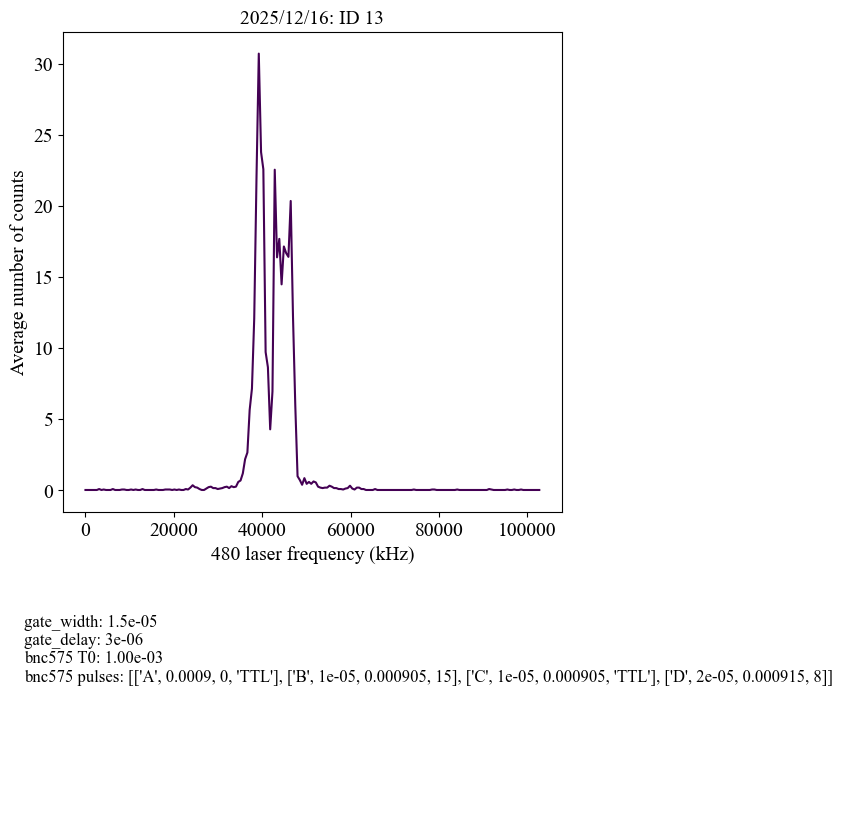

In [46]:
# plot results
ps.Plot2D(x = x_list*stride*freq_factor, y = None, Z = results,
          xlabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

#### 2D maps (small-voltage range)

**Method 1: Frequency scan inside of voltage scan (not using)**

**Method 2: Voltage scan inside of frequency scan (preferred)**

In [ ]:
center = center
stride = 1
half_width = 200

# scan list gneration
s_list = np.arange(2* half_width/stride)

# list of voltage setpoints
#vset = np.array([0.2,-0.1,0.48])
#vset = np.array([0.19,-0.12,0.67])
vset = np.array([0.2,-0.1,0.6])

num_voltages = 11

vx_list = np.linspace(-10.0,10.0,num_voltages) + vset[0]
vy_list = np.linspace(-10.0,10.0,num_voltages) + vset[1]
vz_list = np.linspace(-10.0,10.0,num_voltages) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

electrode_pair = [[10,11],[6,7],[0,1]]

In [ ]:
mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = vset[0], bipolar = True, display = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -vset[0], bipolar = True, display = True)

mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vset[1], bipolar = True, display = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vset[1], bipolar = True, display = True)

mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vset[2], bipolar = True, display = True)

In [ ]:
start_position = center - half_width

stark_map = []

# choose axis: x = 0, y = 1, z = 2
i = 0

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)

for s in s_list:
    for j in range(stride):
            weeder.step("A", "+")
    print(f"Now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in v_list[i]:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display = False)
        else:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display = False)
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display = False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
        results.append(result)
        
    stark_map.append(results)

In [ ]:
ps.Plot3D(x = v_list[i], y = s_list*stride*freq_factor, Z = np.array(stark_map).T,
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

#### 2D Stark maps (full voltage range)

In [11]:
center = center
stride = 2
half_width = 300

# scan list gneration
s_list = np.arange(2*half_width/stride)

# the 0 point

#vset = np.array([0.2,-0.1,0.48])
#vset = np.array([0.19,-0.12,0.67])
vset = np.array([0.2,-0.1,0.6])

num_voltages = 51

vx_list = np.linspace(-10.0,10.0,num_voltages) + vset[0]
vy_list = np.linspace(-10.0,10.0,num_voltages) + vset[1]
vz_list = np.linspace(-10.0,10.0,num_voltages) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

electrode_pair = [[10,11],[6,7],[0,1]]

NameError: name 'center' is not defined

In [40]:
mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = vset[0], bipolar = True, display = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -vset[0], bipolar = True, display = True)

mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vset[1], bipolar = True, display = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vset[1], bipolar = True, display = True)

mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display = True)
mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vset[2], bipolar = True, display = True)

Channel 10 has been set to 0.2 V.
Channel 11 has been set to -0.2 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 0 has been set to 0 V.
Channel 1 has been set to -0.6 V.


In [5]:
# helper function for checking that test voltages stay within MC box's range (-10 to 10 V) (VERSION 2)
# with this version, the entire voltage range is scanned, but the step size is still not completely uniform
def generate_test_voltages(voltages, setpoints, axis: int):
    actual_voltages = []
    vmin, vmax = -10.0, 10.0
    
    for v in voltages[axis]:
        if v <= vmax and v >= vmin:
            actual_voltages.append(v)
        elif v > vmax:
            v -= abs(setpoints[axis])
            actual_voltages.append(v)
        else:
            v += abs(setpoints[axis])
            actual_voltages.append(v)

    v_actual_min = min(actual_voltages)
    v_actual_max = max(actual_voltages)

    min_index = actual_voltages.index(v_actual_min)
    max_index = actual_voltages.index(v_actual_max)

    actual_voltages[min_index] = vmin
    actual_voltages[max_index] = vmax
        
    return actual_voltages

In [43]:
start_position = center - half_width

stark_map = []

# electrode pair to check
i = 0

test_voltages = generate_test_voltages(v_list, vset, axis = i)
print('Voltages to test: \n {}'.format(test_voltages))

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position - 100)
weeder.move(header = "A", position = start_position)

s = time.time()
#print('start:',s)

for s in s_list:
    for j in range(stride):
            weeder.step("A", "+")
    print(f"Now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in test_voltages:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display = False)
        else:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display = False)
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display = False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
        results.append(result)
    
    stark_map.append(results)

e = time.time()
#print('end:',e)
# print('Time elapsed: {} seconds'.format(e-s))

Voltages to test: 
 [-10.0, -9.4, -9.0, -8.600000000000001, -8.200000000000001, -7.8, -7.3999999999999995, -6.999999999999999, -6.6, -6.2, -5.8, -5.3999999999999995, -4.999999999999999, -4.6, -4.199999999999999, -3.8, -3.3999999999999995, -2.999999999999999, -2.5999999999999996, -2.1999999999999993, -1.8, -1.3999999999999997, -0.9999999999999993, -0.599999999999999, -0.19999999999999857, 0.2, 0.6000000000000003, 1.0000000000000007, 1.400000000000001, 1.8000000000000014, 2.2, 2.6000000000000005, 3.000000000000001, 3.4000000000000012, 3.8000000000000016, 4.2, 4.6000000000000005, 5.000000000000001, 5.400000000000001, 5.800000000000002, 6.2, 6.600000000000002, 7.000000000000001, 7.3999999999999995, 7.800000000000002, 8.2, 8.600000000000001, 9.0, 9.400000000000002, 9.8, 10.0]
Now checking axis 0
start at 3150 --> 2550.0 --> 2550
Old position: 3150
New position: 2550
start at 2550 --> 2650.0 --> 2650
Old position: 2550
New position: 2650
Time elapsed: 1765836318.48164 seconds


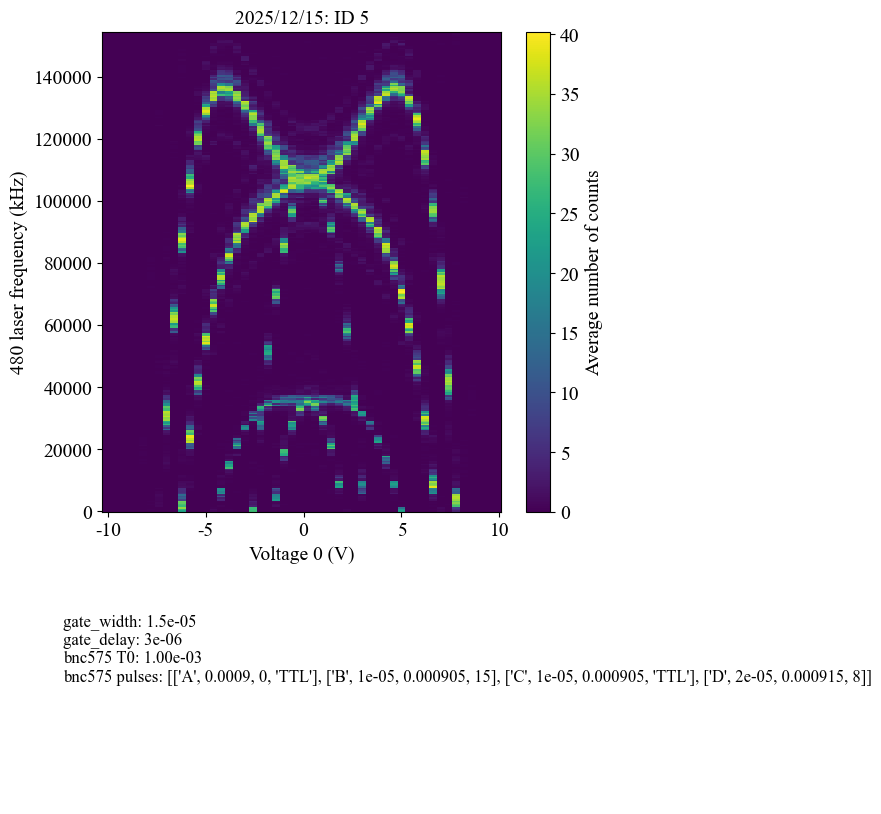

In [44]:
ps.Plot3D(x = test_voltages, y = s_list*stride*freq_factor, Z = np.array(stark_map).T,
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

In [48]:
start_position = center - half_width

stark_map = []

#s = time.time()
for v in test_voltages:
    mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
    mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
    
    # everytime go further and go back to release the band tension and gear margin
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    results = []
    for idx in s_list:
        print(f"Now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A", "+")
        time.sleep(0.1)
    stark_map.append(results)

#e = time.time()
#print('Time elapsed: {} seconds'.format(e-s)

Channel 10 has been set to -10.0 V.
Channel 11 has been set to 10.0 V.
start at 2850 --> 2550.0 --> 2550
Old position: 2850
New position: 2550
start at 2550 --> 2650.0 --> 2650
Old position: 2550
New position: 2650
Channel 10 has been set to -9.4 V.
Channel 11 has been set to 9.4 V.
start at 3250 --> 2550.0 --> 2550
Old position: 3250
New position: 2550
start at 2550 --> 2650.0 --> 2650
Old position: 2550
New position: 2650
Channel 10 has been set to -9.0 V.
Channel 11 has been set to 9.0 V.
start at 3250 --> 2550.0 --> 2550
Old position: 3250
New position: 2550
start at 2550 --> 2650.0 --> 2650
Old position: 2550
New position: 2650
Channel 10 has been set to -8.600000000000001 V.
Channel 11 has been set to 8.600000000000001 V.
start at 3250 --> 2550.0 --> 2550
Old position: 3250
New position: 2550
start at 2550 --> 2650.0 --> 2650
Old position: 2550
New position: 2650
Channel 10 has been set to -8.200000000000001 V.
Channel 11 has been set to 8.200000000000001 V.
start at 3250 --> 255

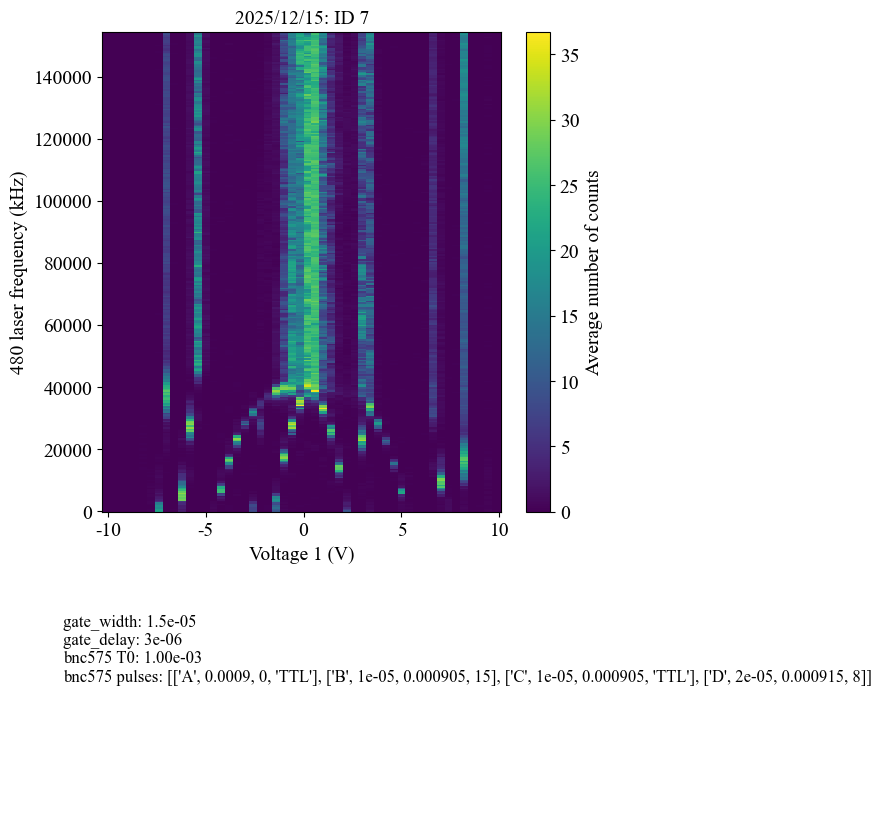

In [50]:
ps.Plot3D(x = test_voltages, y = s_list*stride*freq_factor, Z = np.array(stark_map),
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

In [ ]:
# manual calculation of elapsed time
start = s
end = e
time_elapsed = end - start

print('{} seconds'.format(time_elapsed))

### Peak finding and curve fitting (old code; needs to be updated)

In [ ]:
print(v_list)
print(test_voltages)

In [ ]:
peaks_x = []
peaks_y = []
peaks_list = []
for k in range(len(stark_map[0])):
    freq_scan = np.array(stark_map)[:,k]
    peaks,_ = find_peaks(freq_scan, height = 3, distance = 16)
    print(peaks)
    if len(peaks) == 3:
        for p in peaks:
            peaks_x.append(v_list[i][k])
            peaks_y.append((s_list*stride*freq_factor)[p])
        peaks_list.append(peaks)
peaks_list = np.array(peaks_list)
peaks_x = np.reshape(peaks_x,(-1,3)).T
peaks_y = np.reshape(peaks_y,(-1,3)).T

In [ ]:
plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
ssum = 0 
for l in range(3):
    a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
    plt.scatter(peaks_x[l],peaks_y[l])
    plt.plot(v_list[i], a * v_list[i]**2 + b * v_list[i] +c)
    plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
    plt.xlabel(f"Voltage {i} (V)")
    plt.ylabel("Frequency (kHz)")
    ssum += -b/(2*a)
print(ssum/3)
plt.colorbar()

### Shutting down instrumentation

In [ ]:
mcbox.set_voltage_Nchan(board_num = 0, channels = [0,1,6,7,10,11], voltages = [0,0,0,0,0,0], bipolar = True)

In [ ]:
weeder.save(header = "A", query = True)

In [ ]:
bnc575.disable_all()

In [ ]:
bnc575.disarm_all()

In [ ]:
sr400.count_reset()